# Newborn Hospital Costs — Healthcare Data Science Project
**Goal:** Analyze what factors drive newborn hospitalization costs and build a predictive model for Total Costs.

**Pipeline:**
1. Load & Explore Data
2. Preprocess & Encode
3. Train/Test Split & Scaling
4. Model Comparison (10 models)
5. Random Forest Tuning (GridSearchCV)
6. Feature Importance
7. Healthcare Cost Analysis (CCR, Equity, Facility)

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

## 2. Load & Explore Data

In [3]:
health = pd.read_csv('newborn_costs_cleaned_v3.csv')
health.head().T

,0,1,2,3,4
Operating Certificate Number,7002017,7002017,7002017,7002017,7002017
Permanent Facility Id,1450,1450,1450,1450,1450
Facility Name,LENOX HILL HOSPITAL,LENOX HILL HOSPITAL,LENOX HILL HOSPITAL,LENOX HILL HOSPITAL,LENOX HILL HOSPITAL
Zip Code,OOS,OOS,112,112,104
Gender,F,F,F,F,F
Race,White,Black/African American,White,White,Black/African American
Ethnicity,Not Span/Hispanic,Spanish/Hispanic,Not Span/Hispanic,Not Span/Hispanic,Not Span/Hispanic
Length of Stay,2.0,1.0,1.0,1.0,1.0
Patient Disposition,Home or Self Care,Home or Self Care,Home or Self Care,Home or Self Care,Home or Self Care
CCSR Diagnosis Code,PNL001,PNL001,PNL001,PNL001,PNL001


In [4]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39839 entries, 0 to 39838
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Operating Certificate Number         39839 non-null  int64  
 1   Permanent Facility Id                39839 non-null  int64  
 2   Facility Name                        39839 non-null  object 
 3   Zip Code                             39839 non-null  object 
 4   Gender                               39839 non-null  object 
 5   Race                                 39839 non-null  object 
 6   Ethnicity                            39839 non-null  object 
 7   Length of Stay                       39839 non-null  float64
 8   Patient Disposition                  39839 non-null  object 
 9   CCSR Diagnosis Code                  39839 non-null  object 
 10  CCSR Diagnosis Description           39839 non-null  object 
 11  CCSR Procedure Code         

In [5]:
health.describe()

,Operating Certificate Number,Permanent Facility Id,Length of Stay,APR DRG Code,APR MDC Code,APR Severity of Illness Code,Birth Weight,Total Charges,Total Costs
count,3.983900e+04,39839.000000,39839.000000,39839.000000,39839.000000,39839.000000,39839.000000,3.983900e+04,39839.000000
mean,7.002039e+06,3460.801049,3.782826,637.744672,14.997189,1.478877,3167.757725,7.320122e+04,15385.815501
std,1.684062e+01,3559.408296,8.488238,8.937170,0.193634,0.712041,552.596680,2.462695e+05,54650.836426
min,7.002001e+06,1437.000000,1.000000,115.000000,0.000000,0.000000,400.000000,6.750000e+03,481.530000
25%,7.002024e+06,1456.000000,2.000000,640.000000,15.000000,1.000000,2900.000000,1.965340e+04,1838.230000
50%,7.002053e+06,1464.000000,2.000000,640.000000,15.000000,1.000000,3200.000000,2.436706e+04,3841.820000
75%,7.002054e+06,3975.000000,3.000000,640.000000,15.000000,2.000000,3500.000000,3.644526e+04,8768.825000
max,7.002054e+06,10139.000000,119.000000,956.000000,15.000000,4.000000,6500.000000,4.363635e+06,925448.860000


In [6]:
health.nunique()

Operating Certificate Number               8
Permanent Facility Id                     11
Facility Name                             11
Zip Code                                  27
Gender                                     3
Race                                       4
Ethnicity                                  3
Length of Stay                           117
Patient Disposition                       11
CCSR Diagnosis Code                       19
CCSR Diagnosis Description                19
CCSR Procedure Code                      106
CCSR Procedure Description               107
APR DRG Code                              34
APR DRG Description                       34
APR MDC Code                               5
APR MDC Description                        5
APR Severity of Illness Code               5
APR Severity of Illness Description        5
APR Risk of Mortality                      5
APR Medical Surgical Description           3
Payment Typology 1                         7
Payment Ty

## 3. Preprocessing & Encoding

In [7]:
# Drop description-type columns and Permanent Facility Id
description_columns = [col for col in health.columns if 'description' in col.lower()]
health_simple = health.drop(columns=description_columns)
health_simple = health_simple.drop(columns=['Permanent Facility Id'])
health_simple.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39839 entries, 0 to 39838
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Operating Certificate Number    39839 non-null  int64  
 1   Facility Name                   39839 non-null  object 
 2   Zip Code                        39839 non-null  object 
 3   Gender                          39839 non-null  object 
 4   Race                            39839 non-null  object 
 5   Ethnicity                       39839 non-null  object 
 6   Length of Stay                  39839 non-null  float64
 7   Patient Disposition             39839 non-null  object 
 8   CCSR Diagnosis Code             39839 non-null  object 
 9   CCSR Procedure Code             36110 non-null  object 
 10  APR DRG Code                    39839 non-null  int64  
 11  APR MDC Code                    39839 non-null  int64  
 12  APR Severity of Illness Code    

In [8]:
# One-hot encode all remaining categorical columns
health_encoded = pd.get_dummies(health_simple, columns=health_simple.select_dtypes(include=[object]).columns, drop_first=True)
health_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39839 entries, 0 to 39838
Columns: 203 entries, Operating Certificate Number to Emergency Department Indicator_Y
dtypes: bool(195), float64(4), int64(4)
memory usage: 9.8 MB


## 4. Train/Test Split & Scaling

In [9]:
X = health_encoded.drop(columns='Total Costs')
y = health_encoded['Total Costs']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((31871, 202), (7968, 202), (31871,), (7968,))

In [10]:
# Scale for models that require it (Lasso, Ridge, SVR, MLP)
# Tree-based models (Random Forest, XGBoost) use unscaled data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

## 5. Model Comparison
Comparing 10 regression models across MSE, RMSE, MAE, and R².

In [11]:
# Linear Regression
linear = LinearRegression()
linear.fit(x_train, y_train)
y_pred_linear = linear.predict(x_test)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)
print(f"Linear MSE: {linear_mse}\nLinear RMSE: {linear_rmse}\nLinear MAE: {linear_mae}\nLinear R2: {linear_r2}")

Linear MSE: 135478718.2634487
Linear RMSE: 11639.53256206832
Linear MAE: 4266.9912733749
Linear R2: 0.9628052079566221


In [12]:
# Lasso
lasso = Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_test_scaled)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)
print(f"Lasso MSE: {lasso_mse}\nLasso RMSE: {lasso_rmse}\nLasso MAE: {lasso_mae}\nLasso R2: {lasso_r2}")

Lasso MSE: 135481116.61110288
Lasso RMSE: 11639.635587556118
Lasso MAE: 4264.906486035549
Lasso R2: 0.9628045495060301


c:\Users\NateW\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.358e+10, tolerance: 8.995e+09
  model = cd_fast.enet_coordinate_descent(


In [13]:
# LassoCV
lassocv = LassoCV(alphas=100, cv=cv, max_iter=10000)
lassocv.fit(x_train_scaled, y_train)
y_pred_lassocv = lassocv.predict(x_test_scaled)
lassocv_mse = mean_squared_error(y_test, y_pred_lassocv)
lassocv_rmse = np.sqrt(lassocv_mse)
lassocv_mae = mean_absolute_error(y_test, y_pred_lassocv)
lassocv_r2 = r2_score(y_test, y_pred_lassocv)
print(f"LassoCV MSE: {lassocv_mse}\nLassoCV RMSE: {lassocv_rmse}\nLassoCV MAE: {lassocv_mae}\nLassoCV R2: {lassocv_r2}")

LassoCV MSE: 139039421.53073418
LassoCV RMSE: 11791.497849329158
LassoCV MAE: 4077.6606833465553
LassoCV R2: 0.9618276402673758


In [14]:
# Ridge
ridge = Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)
print(f"Ridge MSE: {ridge_mse}\nRidge RMSE: {ridge_rmse}\nRidge MAE: {ridge_mae}\nRidge R2: {ridge_r2}")

Ridge MSE: 135483689.3507014
Ridge RMSE: 11639.746103360734
Ridge MAE: 4266.550349784185
Ridge R2: 0.9628038431772754


In [15]:
# RidgeCV
ridgecv = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=cv)
ridgecv.fit(x_train_scaled, y_train)
y_pred_ridgecv = ridgecv.predict(x_test_scaled)
ridgecv_mse = mean_squared_error(y_test, y_pred_ridgecv)
ridgecv_rmse = np.sqrt(ridgecv_mse)
ridgecv_mae = mean_absolute_error(y_test, y_pred_ridgecv)
ridgecv_r2 = r2_score(y_test, y_pred_ridgecv)
print(f"RidgeCV MSE: {ridgecv_mse}\nRidgeCV RMSE: {ridgecv_rmse}\nRidgeCV MAE: {ridgecv_mae}\nRidgeCV R2: {ridgecv_r2}")

RidgeCV MSE: 136081188.3596062
RidgeCV RMSE: 11665.384192541891
RidgeCV MAE: 4226.77488335062
RidgeCV R2: 0.9626398037497756


In [16]:
# Random Forest (baseline, before tuning)
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x_train, y_train)
y_pred_rfr = rfr.predict(x_test)
rfr_mse = mean_squared_error(y_test, y_pred_rfr)
rfr_rmse = np.sqrt(rfr_mse)
rfr_mae = mean_absolute_error(y_test, y_pred_rfr)
rfr_r2 = r2_score(y_test, y_pred_rfr)
print(f"Random Forest MSE: {rfr_mse}\nRandom Forest RMSE: {rfr_rmse}\nRandom Forest MAE: {rfr_mae}\nRandom Forest R2: {rfr_r2}")

Random Forest MSE: 23319010.281978656
Random Forest RMSE: 4828.976111141849
Random Forest MAE: 609.7072017068278
Random Forest R2: 0.9935979189262112


In [17]:
# SVR - Linear kernel
svr_lin = SVR(kernel='linear')
svr_lin.fit(x_train_scaled, y_train)
y_pred_svr_lin = svr_lin.predict(x_test_scaled)
svr_lin_mse = mean_squared_error(y_test, y_pred_svr_lin)
svr_lin_rmse = np.sqrt(svr_lin_mse)
svr_lin_mae = mean_absolute_error(y_test, y_pred_svr_lin)
svr_lin_r2 = r2_score(y_test, y_pred_svr_lin)
print(f"SVR Linear MSE: {svr_lin_mse}\nSVR Linear RMSE: {svr_lin_rmse}\nSVR Linear MAE: {svr_lin_mae}\nSVR Linear R2: {svr_lin_r2}")

SVR Linear MSE: 1817646056.6272418
SVR Linear RMSE: 42633.86044715212
SVR Linear MAE: 8786.165062648914
SVR Linear R2: 0.5009772165599524


In [18]:
# SVR - RBF kernel
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(x_train_scaled, y_train)
y_pred_svr_rbf = svr_rbf.predict(x_test_scaled)
svr_rbf_mse = mean_squared_error(y_test, y_pred_svr_rbf)
svr_rbf_rmse = np.sqrt(svr_rbf_mse)
svr_rbf_mae = mean_absolute_error(y_test, y_pred_svr_rbf)
svr_rbf_r2 = r2_score(y_test, y_pred_svr_rbf)
print(f"SVR RBF MSE: {svr_rbf_mse}\nSVR RBF RMSE: {svr_rbf_rmse}\nSVR RBF MAE: {svr_rbf_mae}\nSVR RBF R2: {svr_rbf_r2}")

SVR RBF MSE: 3791486093.1841693
SVR RBF RMSE: 61575.0444026163
SVR RBF MAE: 14362.328693330766
SVR RBF R2: -0.04092759792068246


In [19]:
# XGBoost
xgboost = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgboost.fit(x_train, y_train)
y_pred_xgboost = xgboost.predict(x_test)
xgboost_mse = mean_squared_error(y_test, y_pred_xgboost)
xgboost_rmse = np.sqrt(xgboost_mse)
xgboost_mae = mean_absolute_error(y_test, y_pred_xgboost)
xgboost_r2 = r2_score(y_test, y_pred_xgboost)
print(f"XGBoost MSE: {xgboost_mse}\nXGBoost RMSE: {xgboost_rmse}\nXGBoost MAE: {xgboost_mae}\nXGBoost R2: {xgboost_r2}")

XGBoost MSE: 39163601.29820943
XGBoost RMSE: 6258.082877224417
XGBoost MAE: 1045.173393852816
XGBoost R2: 0.9892478905570686


In [20]:
# MLP Regressor
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(x_train_scaled, y_train)
y_pred_mlp = mlp.predict(x_test_scaled)
mlp_mse = mean_squared_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mlp_mse)
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_r2 = r2_score(y_test, y_pred_mlp)
print(f"MLP MSE: {mlp_mse}\nMLP RMSE: {mlp_rmse}\nMLP MAE: {mlp_mae}\nMLP R2: {mlp_r2}")

MLP MSE: 95838345.93001868
MLP RMSE: 9789.706120717756
MLP MAE: 2931.429584732858
MLP R2: 0.973688211755026


c:\Users\NateW\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
# --- Model Comparison Summary Table ---
models = ['Linear', 'Lasso', 'LassoCV', 'Ridge', 'RidgeCV', 'Random Forest', 'SVR Linear', 'SVR RBF', 'XGBoost', 'MLP']
mse    = [linear_mse, lasso_mse, lassocv_mse, ridge_mse, ridgecv_mse, rfr_mse, svr_lin_mse, svr_rbf_mse, xgboost_mse, mlp_mse]
rmse   = [linear_rmse, lasso_rmse, lassocv_rmse, ridge_rmse, ridgecv_rmse, rfr_rmse, svr_lin_rmse, svr_rbf_rmse, xgboost_rmse, mlp_rmse]
mae    = [linear_mae, lasso_mae, lassocv_mae, ridge_mae, ridgecv_mae, rfr_mae, svr_lin_mae, svr_rbf_mae, xgboost_mae, mlp_mae]
r2     = [linear_r2, lasso_r2, lassocv_r2, ridge_r2, ridgecv_r2, rfr_r2, svr_lin_r2, svr_rbf_r2, xgboost_r2, mlp_r2]

df_scores = pd.DataFrame({'Model': models, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
print(df_scores.sort_values('R2', ascending=False).to_string(index=False))

        Model          MSE         RMSE          MAE        R2
Random Forest 2.331901e+07  4828.976111   609.707202  0.993598
      XGBoost 3.916360e+07  6258.082877  1045.173394  0.989248
          MLP 9.583835e+07  9789.706121  2931.429585  0.973688
       Linear 1.354787e+08 11639.532562  4266.991273  0.962805
        Lasso 1.354811e+08 11639.635588  4264.906486  0.962805
        Ridge 1.354837e+08 11639.746103  4266.550350  0.962804
      RidgeCV 1.360812e+08 11665.384193  4226.774883  0.962640
      LassoCV 1.390394e+08 11791.497849  4077.660683  0.961828
   SVR Linear 1.817646e+09 42633.860447  8786.165063  0.500977
      SVR RBF 3.791486e+09 61575.044403 14362.328693 -0.040928


C:\Users\NateW\AppData\Local\Temp\ipykernel_11396\2696352536.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scores_sorted, x='R2', y='Model', palette='Blues_r')


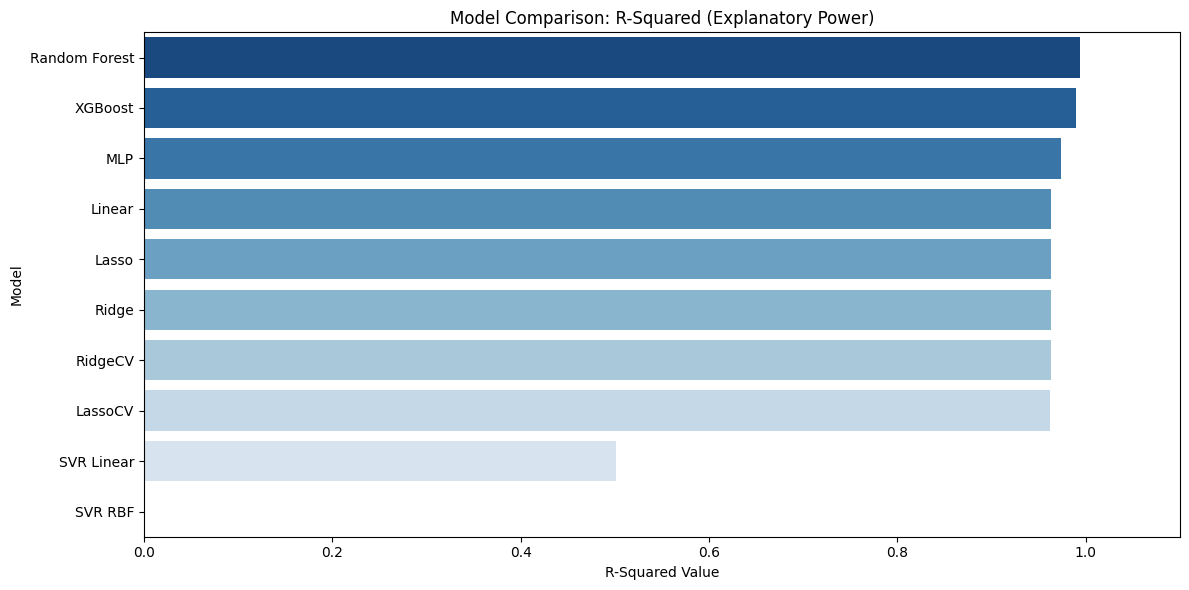

C:\Users\NateW\AppData\Local\Temp\ipykernel_11396\2696352536.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mae_sorted, x='MAE', y='Model', palette='Oranges')


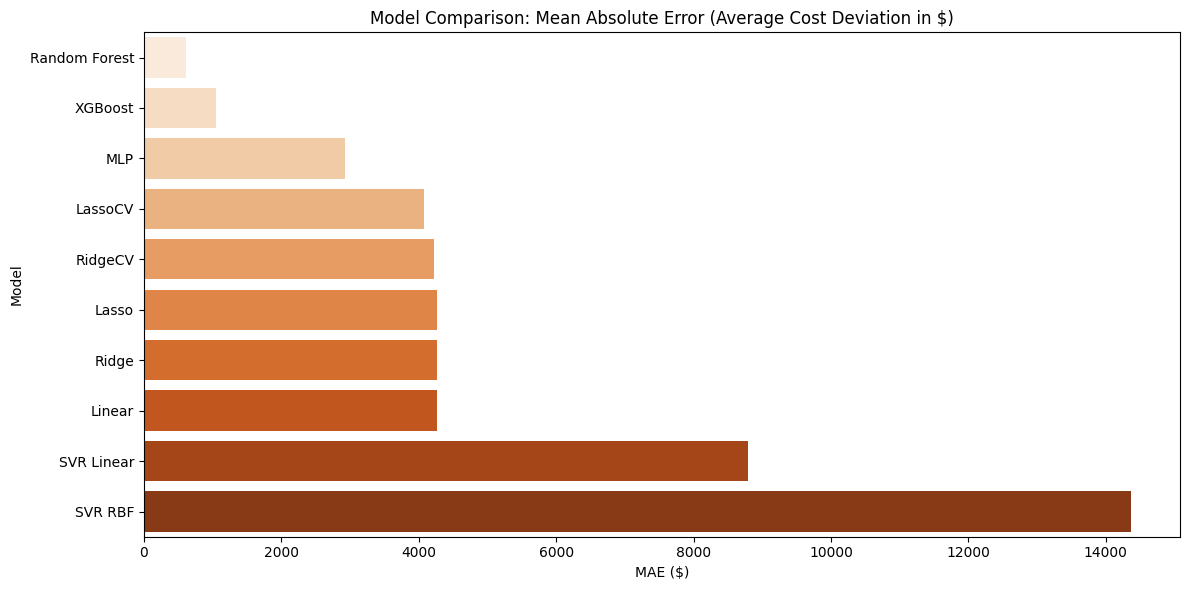

In [22]:
# --- Model Comparison Visualizations ---
df_scores_sorted = df_scores.sort_values(by='R2', ascending=False)

# R-Squared Comparison (higher is better)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_scores_sorted, x='R2', y='Model', palette='Blues_r')
plt.title('Model Comparison: R-Squared (Explanatory Power)')
plt.xlabel('R-Squared Value')
plt.xlim(0, 1.1)
plt.tight_layout()
plt.savefig('r2_comparison.png')
plt.show()

# Mean Absolute Error (lower is better)
df_mae_sorted = df_scores.sort_values(by='MAE', ascending=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_mae_sorted, x='MAE', y='Model', palette='Oranges')
plt.title('Model Comparison: Mean Absolute Error (Average Cost Deviation in $)')
plt.xlabel('MAE ($)')
plt.tight_layout()
plt.savefig('mae_comparison.png')
plt.show()

## 6. Random Forest Hyperparameter Tuning (GridSearchCV)
Random Forest outperformed all other models. We now tune it with GridSearchCV to find the best parameters.

**Reference:** https://www.geeksforgeeks.org/random-forest-hyperparameter-tuning-in-python/

In [23]:
param_grid = {
    'n_estimators': [50, 100, 125, 150, 175, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Estimator: RandomForestRegressor(max_features='sqrt', random_state=42)


In [ ]:
best_params = grid_search.best_params_

model_tuned = RandomForestRegressor(
    n_estimators=best_params.get('n_estimators', 125),
    max_depth=best_params.get('max_depth', None),
    min_samples_split=best_params.get('min_samples_split', 2),
    min_samples_leaf=best_params.get('min_samples_leaf', 1),
    max_features=best_params.get('max_features', 'sqrt'),
    random_state=42
)
model_tuned.fit(x_train, y_train)
y_pred_tuned = model_tuned.predict(x_test)

tuned_mse  = mean_squared_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)
tuned_mae  = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2   = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest MSE:  {tuned_mse}")
print(f"Tuned Random Forest RMSE: {tuned_rmse}")
print(f"Tuned Random Forest MAE:  {tuned_mae}")
print(f"Tuned Random Forest R2:   {tuned_r2}")

Tuned Random Forest MSE:  169002712.7039582
Tuned Random Forest RMSE: 13000.104334348944
Tuned Random Forest MAE:  2360.8880229794177
Tuned Random Forest R2:   0.9536014155258923


In [39]:
model_tuned = RandomForestRegressor(n_estimators=125, random_state=42)
model_tuned.fit(x_train, y_train)
y_pred_tuned = model_tuned.predict(x_test)

tuned_mse  = mean_squared_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)
tuned_mae  = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2   = r2_score(y_test, y_pred_tuned)

print(f"Updated Random Forest MSE:  {tuned_mse}")
print(f"Updated Random Forest RMSE: {tuned_rmse}")
print(f"Updated Random Forest MAE:  {tuned_mae}")
print(f"Updated Random Forest R2:   {tuned_r2}")

Updated Random Forest MSE:  22895074.004233193
Updated Random Forest RMSE: 4784.879727248449
Updated Random Forest MAE:  606.2374717771096
Updated Random Forest R2:   0.9937143078461279


## 7. Feature Importance
Using the tuned Random Forest to identify which predictors drive Total Costs the most.

**Reference:** https://medium.com/data-science/improving-random-forest-in-python-part-1-893916666cd

In [25]:
# Feature importance from the full encoded model
feature_list = list(X.columns)
importances = list(model_tuned.feature_importances_)
feature_importances = [(feature, round(importance, 4)) for feature, importance in zip(feature_list, importances)]
feature_importances = sorted(feature_importances, key=lambda x: x[1], reverse=True)

print("Top 20 Features by Importance:")
[print('Variable: {:40} Importance: {}'.format(*pair)) for pair in feature_importances[:20]]

Top 20 Features by Importance:
Variable: Length of Stay                           Importance: 0.3024
Variable: Total Charges                            Importance: 0.1935
Variable: APR DRG Code                             Importance: 0.1468
Variable: Birth Weight                             Importance: 0.0787
Variable: APR Risk of Mortality_Minor              Importance: 0.0403
Variable: APR Risk of Mortality_Major              Importance: 0.0344
Variable: APR Severity of Illness Code             Importance: 0.0309
Variable: CCSR Procedure Code_CAR024               Importance: 0.0142
Variable: APR Risk of Mortality_Moderate           Importance: 0.0099
Variable: CCSR Procedure Code_ESA004               Importance: 0.0094
Variable: Patient Disposition_Home or Self Care    Importance: 0.0093
Variable: Operating Certificate Number             Importance: 0.0086
Variable: Facility Name_NYU LANGONE HOSPITALS      Importance: 0.0071
Variable: Facility Name_MOUNT SINAI HOSPITAL       Importan

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

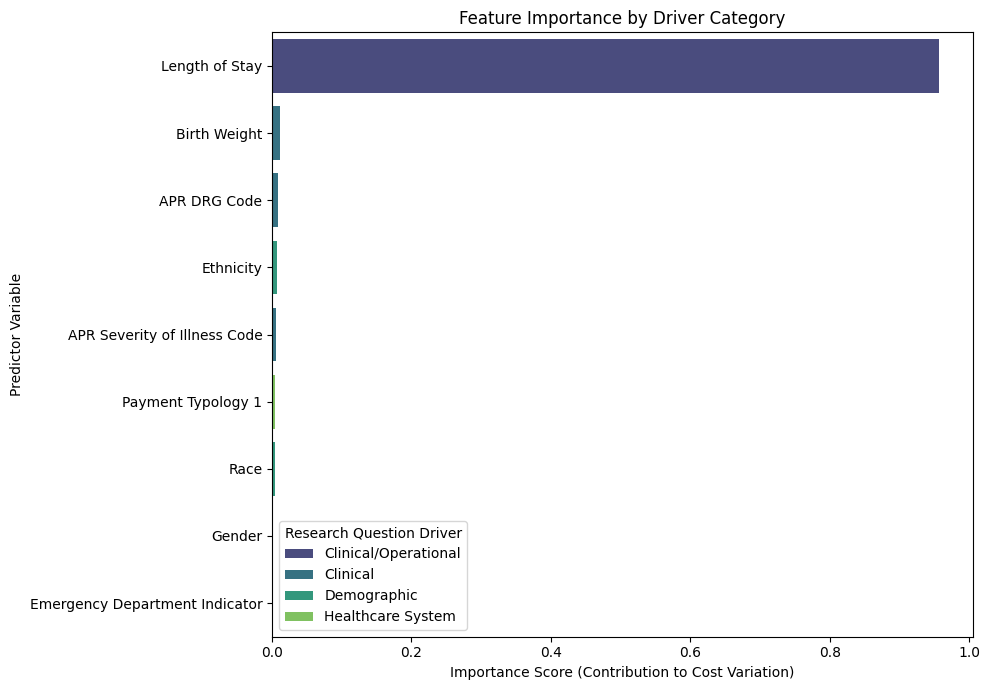

C:\Users\NateW\AppData\Local\Temp\ipykernel_11396\512043023.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_importance, x='Importance', y='Category', palette='magma')


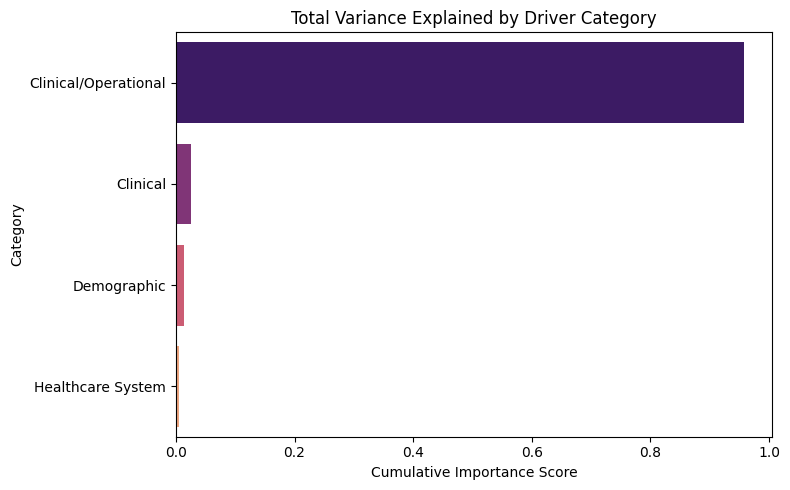

Feature Importance Data:
                          Feature  Importance              Category
2                  Length of Stay    0.957114  Clinical/Operational
0                    Birth Weight    0.011638              Clinical
3                    APR DRG Code    0.008187              Clinical
6                       Ethnicity    0.007845           Demographic
1    APR Severity of Illness Code    0.005124              Clinical
7              Payment Typology 1    0.004484     Healthcare System
5                            Race    0.003966           Demographic
4                          Gender    0.001513           Demographic
8  Emergency Department Indicator    0.000129     Healthcare System

Grouped Importance (by Category):
               Category  Importance
1  Clinical/Operational    0.957114
0              Clinical    0.024949
2           Demographic    0.013324
3     Healthcare System    0.004613


In [26]:
# --- Feature Importance by Research Driver Category ---
# Focused model using interpretable clinical, demographic, and system features
clinical_cols    = ['Birth Weight', 'APR Severity of Illness Code', 'Length of Stay', 'APR DRG Code']
demographic_cols = ['Gender', 'Race', 'Ethnicity']
system_cols      = ['Payment Typology 1', 'Emergency Department Indicator']

all_features = clinical_cols + demographic_cols + system_cols
X_interp = health[all_features].copy()
y_interp = health['Total Costs']

le = LabelEncoder()
for col in demographic_cols + system_cols:
    X_interp[col] = le.fit_transform(X_interp[col].astype(str))

rf_interp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_interp.fit(X_interp, y_interp)

importance_df = pd.DataFrame({'Feature': all_features, 'Importance': rf_interp.feature_importances_})

category_map = {
    'Birth Weight': 'Clinical',
    'APR Severity of Illness Code': 'Clinical',
    'Length of Stay': 'Clinical/Operational',
    'APR DRG Code': 'Clinical',
    'Gender': 'Demographic',
    'Race': 'Demographic',
    'Ethnicity': 'Demographic',
    'Payment Typology 1': 'Healthcare System',
    'Emergency Department Indicator': 'Healthcare System'
}
importance_df['Category'] = importance_df['Feature'].map(category_map)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bridge graph: feature importance colored by research category
plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Category', palette='viridis', dodge=False)
plt.title('Feature Importance by Driver Category')
plt.xlabel('Importance Score (Contribution to Cost Variation)')
plt.ylabel('Predictor Variable')
plt.legend(title='Research Question Driver')
plt.tight_layout()
plt.savefig('bridge_math_to_mission.png')
plt.show()

# Grouped importance by category
grouped_importance = importance_df.groupby('Category')['Importance'].sum().reset_index().sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=grouped_importance, x='Importance', y='Category', palette='magma')
plt.title('Total Variance Explained by Driver Category')
plt.xlabel('Cumulative Importance Score')
plt.tight_layout()
plt.savefig('category_importance_summary.png')
plt.show()

print("Feature Importance Data:")
print(importance_df)
print("\nGrouped Importance (by Category):")
print(grouped_importance)

## 8. Healthcare Cost Analysis
Beyond prediction, we explore cost patterns across clinical, demographic, and system factors using Cost-to-Charge Ratio (CCR) and raw cost comparisons.

In [27]:
# Derived cost metrics
health['Cost_Percentage_CCR'] = (health['Total Costs'] / health['Total Charges']) * 100
health['Gross_Margin_Dollars'] = health['Total Charges'] - health['Total Costs']

print(f"Overall average Cost-to-Charge Ratio: {health['Cost_Percentage_CCR'].mean():.2f}%")

Overall average Cost-to-Charge Ratio: 19.11%


In [28]:
# TABLE 1: Facility Pricing Strategy
# Lowest CCR = Highest markup between charges and actual costs
facility_pricing = health.groupby('Facility Name').agg(
    Total_Newborns=('Total Costs', 'count'),
    Avg_Cost=('Total Costs', 'mean'),
    Avg_Charge=('Total Charges', 'mean'),
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean')
).sort_values('Avg_CCR_Percentage', ascending=True)

print("--- System Driver: Facility Pricing Strategies (sorted by CCR, lowest = highest markup) ---")
print(facility_pricing)

--- System Driver: Facility Pricing Strategies (sorted by CCR, lowest = highest markup) ---
                                                    Total_Newborns  \
Facility Name                                                        
NEW YORK-PRESBYTERIAN HOSPITAL - ALLEN HOSPITAL               1832   
NEW YORK-PRESBYTERIAN DAVID H. KOCH CENTER                    8664   
NEW YORK-PRESBYTERIAN/LOWER MANHATTAN HOSPITAL                1966   
NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRESB...            4043   
MOUNT SINAI HOSPITAL                                          5751   
LENOX HILL HOSPITAL                                           3645   
MOUNT SINAI WEST                                              5479   
NYU LANGONE HOSPITALS                                         5048   
BELLEVUE HOSPITAL CENTER                                      1592   
METROPOLITAN HOSPITAL CENTER                                  1152   
HARLEM HOSPITAL CENTER                                         667  

In [29]:
# TABLE 2: Financial Exposure by Severity
clinical_risk = health.groupby('APR Severity of Illness Description').agg(
    Avg_Cost=('Total Costs', 'mean'),
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean'),
    Avg_Margin_Dollars=('Gross_Margin_Dollars', 'mean')
).sort_values('Avg_Cost', ascending=True)

print("--- Clinical Driver: Financial Exposure by Severity ---")
print(clinical_risk)

--- Clinical Driver: Financial Exposure by Severity ---
                                          Avg_Cost  Avg_CCR_Percentage  \
APR Severity of Illness Description                                      
Minor                                  6103.852212           18.560985   
Moderate                              16095.507469           19.104708   
Major                                 44441.579006           21.961616   
Undetermined                          66498.315000           21.901487   
Extreme                              293360.920263           25.918615   

                                     Avg_Margin_Dollars  
APR Severity of Illness Description                      
Minor                                      25666.747164  
Moderate                                   63667.512296  
Major                                     154515.019770  
Undetermined                              236341.673333  
Extreme                                   975103.602792  


In [30]:
# TABLE 3: Cost Percentage by Payer (Payment Typology)
payer_equity = health.groupby('Payment Typology 1').agg(
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean'),
    Total_Patients=('Cost_Percentage_CCR', 'count')
).sort_values('Total_Patients', ascending=False)

print("--- Demographic Driver: Cost Percentage by Payer ---")
print(payer_equity)

--- Demographic Driver: Cost Percentage by Payer ---
                           Avg_CCR_Percentage  Total_Patients
Payment Typology 1                                           
Private Health Insurance            16.351334           20649
Medicaid                            25.736821           10857
Blue Cross/Blue Shield              17.707265            4883
Medicare                            15.607845            2563
Self-Pay                            19.930419             875
Managed Care, Unspecified           15.327620              10
Miscellaneous/Other                 32.069474               2


In [31]:
# TABLE 4: Cost & Equity by Race
race_equity = health.groupby('Race').agg(
    Total_Patients=('Total Costs', 'count'),
    Avg_Cost=('Total Costs', 'mean'),
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean'),
    Avg_Margin_Dollars=('Gross_Margin_Dollars', 'mean')
).sort_values('Avg_Cost', ascending=False)

print("--- Demographic Driver: Cost and Equity by Race ---")
print(race_equity)

--- Demographic Driver: Cost and Equity by Race ---
                        Total_Patients      Avg_Cost  Avg_CCR_Percentage  \
Race                                                                       
Black/African American            4250  21087.561922           23.964837   
Other Race                       15171  16719.875590           21.579636   
Multi-racial                      2236  14947.374047           11.459049   
White                            18182  12993.829317           16.847967   

                        Avg_Margin_Dollars  
Race                                        
Black/African American        70976.871638  
Other Race                    59475.445120  
Multi-racial                  70579.080076  
White                         51784.150592  


In [32]:
# TABLE 5: Cost & Equity by Ethnicity
ethnicity_equity = health.groupby('Ethnicity').agg(
    Total_Patients=('Total Costs', 'count'),
    Avg_Cost=('Total Costs', 'mean'),
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean')
).sort_values('Avg_Cost', ascending=False)

print("--- Demographic Driver: Cost and Equity by Ethnicity ---")
print(ethnicity_equity)

--- Demographic Driver: Cost and Equity by Ethnicity ---
                   Total_Patients      Avg_Cost  Avg_CCR_Percentage
Ethnicity                                                          
Unknown                      8532  22686.189673           35.415519
Spanish/Hispanic             8403  14869.369716           17.731743
Not Span/Hispanic           22904  12855.816440           13.535729


In [33]:
# TABLE 6: Cost & Equity by Gender
gender_equity = health.groupby('Gender').agg(
    Total_Patients=('Total Costs', 'count'),
    Avg_Cost=('Total Costs', 'mean'),
    Avg_CCR_Percentage=('Cost_Percentage_CCR', 'mean')
).sort_values('Avg_Cost', ascending=False)

print("--- Demographic Driver: Cost and Equity by Gender ---")
print(gender_equity)

--- Demographic Driver: Cost and Equity by Gender ---
        Total_Patients      Avg_Cost  Avg_CCR_Percentage
Gender                                                  
U                    6  17227.795000           42.889040
M                20429  16259.530420           19.343536
F                19404  14465.377759           18.849771


In [34]:
# APR Risk of Mortality vs CCR
print("--- CCR by APR Risk of Mortality ---")
print(health.groupby('APR Risk of Mortality')['Cost_Percentage_CCR'].mean())

--- CCR by APR Risk of Mortality ---
APR Risk of Mortality
Extreme         23.648918
Major           27.416044
Minor           18.768332
Moderate        25.194799
Undetermined    21.901487
Name: Cost_Percentage_CCR, dtype: float64


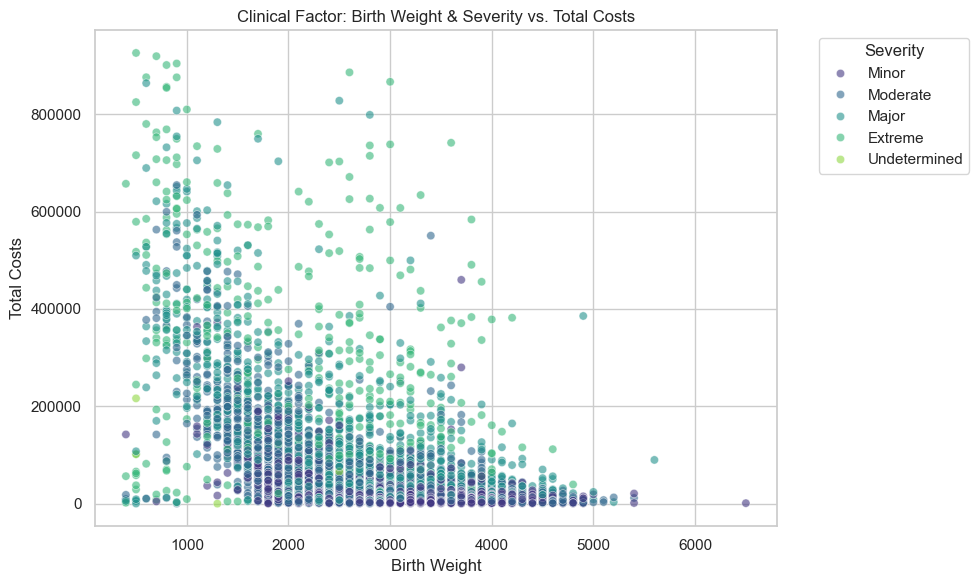

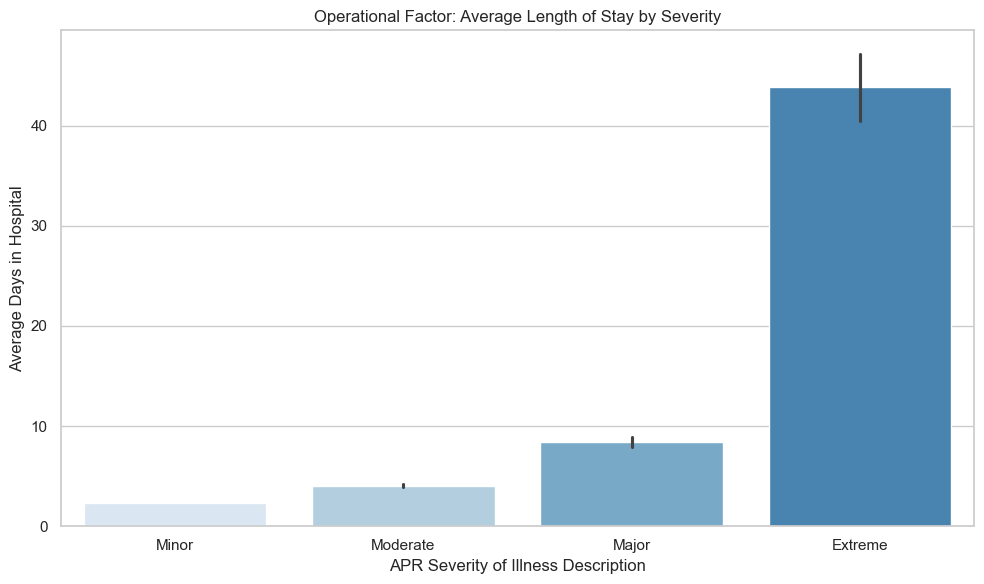

In [35]:
# --- Visualization: Clinical Factors ---
sns.set_theme(style='whitegrid')

# Birth Weight & Severity vs Total Costs
plt.figure(figsize=(10, 6))
sns.scatterplot(data=health, x='Birth Weight', y='Total Costs',
                hue='APR Severity of Illness Description', palette='viridis', alpha=0.6)
plt.title('Clinical Factor: Birth Weight & Severity vs. Total Costs')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('clinical_drivers_colored.png')
plt.show()

# Length of Stay by Severity
plt.figure(figsize=(10, 6))
sns.barplot(data=health, x='APR Severity of Illness Description', y='Length of Stay',
            order=['Minor', 'Moderate', 'Major', 'Extreme'],
            hue='APR Severity of Illness Description', palette='Blues')
plt.title('Operational Factor: Average Length of Stay by Severity')
plt.ylabel('Average Days in Hospital')
plt.tight_layout()
plt.savefig('los_by_severity.png')
plt.show()

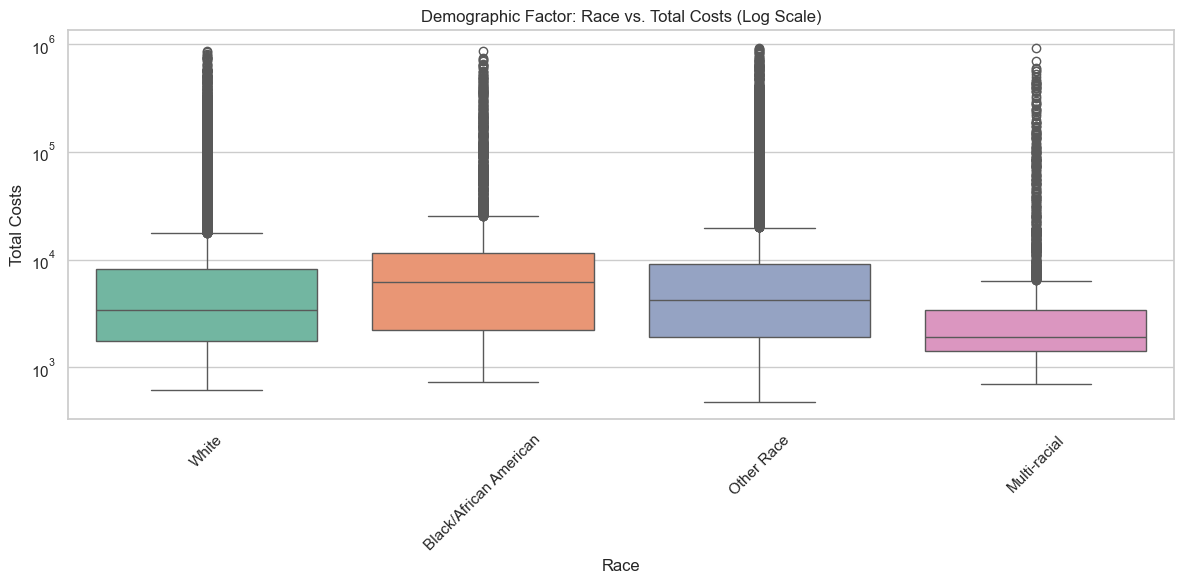

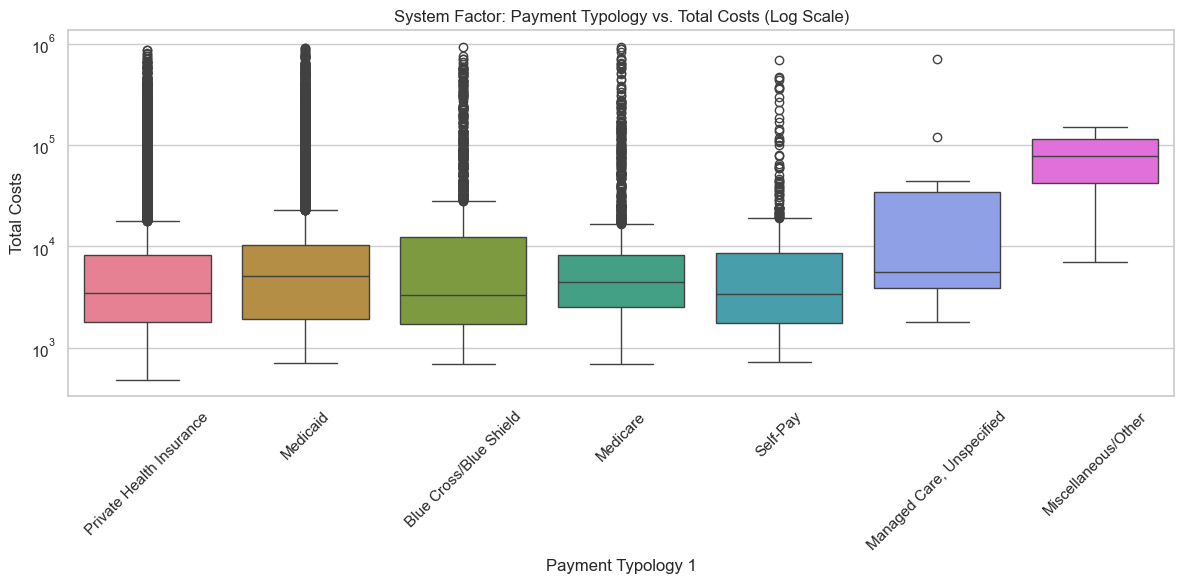

In [36]:
# --- Visualization: Demographic Factors ---

# Race vs Total Costs
plt.figure(figsize=(12, 6))
sns.boxplot(data=health, x='Race', y='Total Costs', hue='Race', palette='Set2')
plt.xticks(rotation=45)
plt.title('Demographic Factor: Race vs. Total Costs (Log Scale)')
plt.yscale('log')
plt.tight_layout()
plt.savefig('demographic_drivers_colored.png')
plt.show()

# Payment Typology vs Total Costs
plt.figure(figsize=(12, 6))
sns.boxplot(data=health, x='Payment Typology 1', y='Total Costs', hue='Payment Typology 1', palette='husl')
plt.xticks(rotation=45)
plt.title('System Factor: Payment Typology vs. Total Costs (Log Scale)')
plt.yscale('log')
plt.tight_layout()
plt.savefig('system_drivers_colored.png')
plt.show()

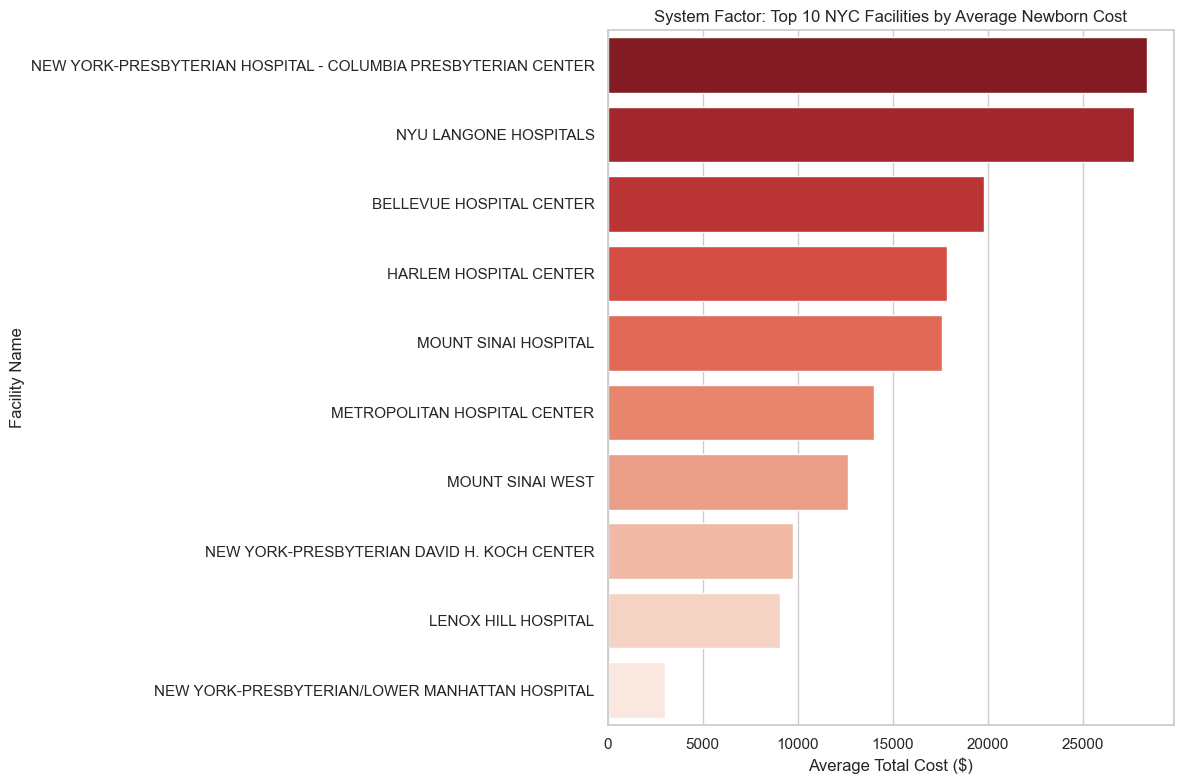

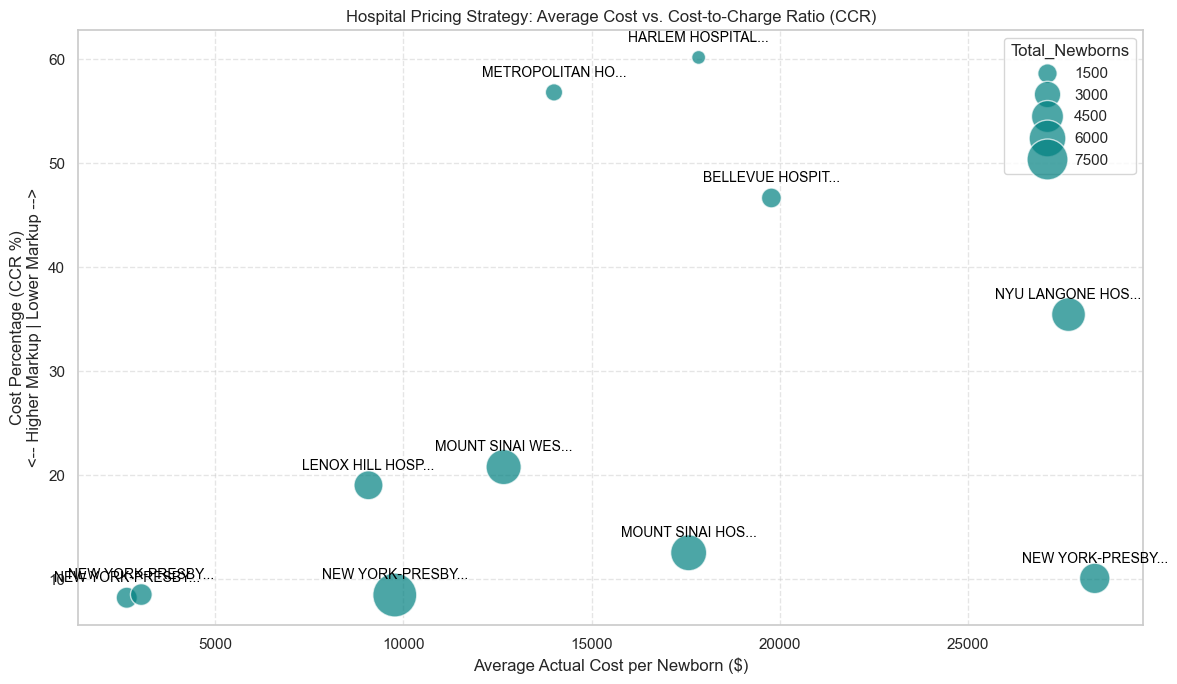

In [37]:
# --- Visualization: System Factors ---

# Top 10 Facilities by Average Cost
top_10_hospitals = health.groupby('Facility Name')['Total Costs'].mean().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_hospitals, x='Total Costs', y='Facility Name', hue='Facility Name', palette='Reds_r')
plt.title('System Factor: Top 10 NYC Facilities by Average Newborn Cost')
plt.xlabel('Average Total Cost ($)')
plt.tight_layout()
plt.savefig('facility_cost_comparison.png')
plt.show()

# Facility Pricing Strategy: Cost vs CCR Scatter
plt.figure(figsize=(12, 7))
sns.scatterplot(data=facility_pricing,
                x='Avg_Cost',
                y='Avg_CCR_Percentage',
                size='Total_Newborns',
                sizes=(100, 1000),
                alpha=0.7,
                color='teal')
for i in range(facility_pricing.shape[0]):
    plt.text(facility_pricing['Avg_Cost'].iloc[i],
             facility_pricing['Avg_CCR_Percentage'].iloc[i] + 1.5,
             facility_pricing.index[i][:15] + '...',
             horizontalalignment='center', size='small', color='black')
plt.title('Hospital Pricing Strategy: Average Cost vs. Cost-to-Charge Ratio (CCR)')
plt.xlabel('Average Actual Cost per Newborn ($)')
plt.ylabel('Cost Percentage (CCR %)\n<-- Higher Markup | Lower Markup -->')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('executive_pricing_strategy.png')
plt.show()